In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data = pd.read_csv("../../datasets/house-price-prediction/train.csv")

In [10]:
data["GarageYrBlt"].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: GarageYrBlt, Length: 1460, dtype: bool

In [11]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [12]:
data.isnull().sum().sum()

7829

<Axes: >

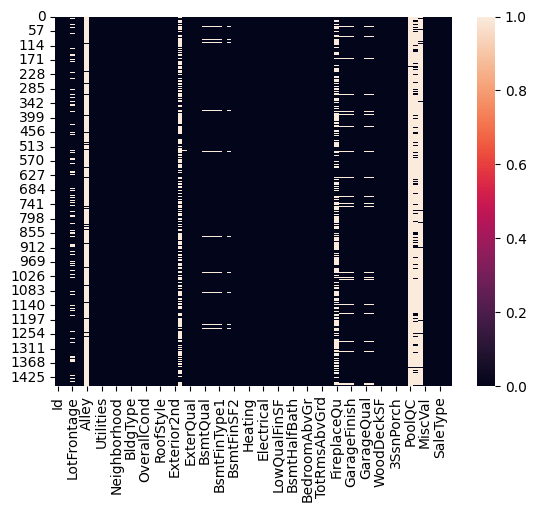

In [13]:
sns.heatmap(data.isnull())

In [14]:
missing_stats = pd.DataFrame({
    "missing_count": data.isnull().sum(),
    "missing_%": data.isnull().mean() * 100
})

missing_stats = missing_stats.sort_values(by="missing_%", ascending=False)
missing_stats = missing_stats[missing_stats["missing_count"] > 0]
print(missing_stats)

              missing_count  missing_%
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageYrBlt              81   5.547945
GarageCond               81   5.547945
GarageType               81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtQual                 37   2.534247
BsmtCond                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


In [15]:
data = data.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence'], axis = 1)
print("columns dropped")

columns dropped


In [16]:
data = data.drop("MasVnrType", axis = 1)
print("dropped")

dropped


In [17]:
data["FireplaceQu"] = data["FireplaceQu"].fillna("NA")
print("filled")

filled


In [18]:
data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].mean())
print("filled")

filled


In [19]:
data["GarageType"] = data["GarageType"].fillna("NA")
print("filled")

filled


In [20]:
data["GarageYrBlt"] = data["GarageYrBlt"].fillna(data["GarageYrBlt"].mode()[0])
print("filled")

filled


In [21]:
data["GarageFinish"] = data["GarageFinish"].fillna("NA")
print("filled")

filled


In [22]:
data["GarageQual"] = data["GarageQual"].fillna("NA")
print("filled")

filled


In [23]:
data["GarageCond"] = data["GarageCond"].fillna("NA")
print("filled")

filled


In [24]:
data["BsmtFinType2"] = data ["BsmtFinType2"].fillna("NA")   
data["BsmtExposure"] = data ["BsmtExposure"].fillna("NA")
data["BsmtFinType1"] = data ["BsmtFinType1"].fillna("NA")       
data["BsmtQual"] = data ["BsmtQual"].fillna("NA")
data["BsmtCond"] = data ["BsmtCond"].fillna("NA")   

print("filled")

filled


In [25]:
data["MasVnrArea"] = data["MasVnrArea"].fillna(data["MasVnrArea"].mean())
print("filled")

filled


In [26]:
data["Electrical"] = data["Electrical"].fillna("NA")
print("filled")

filled


In [27]:
data = data.loc[:, data.nunique() > 1]

In [28]:
num_cols = data.select_dtypes(include = "number").columns

Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)

IQR = Q3-Q1

outliers = (data[num_cols] < (Q1 - 1.5*IQR)) | (data[num_cols] > (Q3 + 1.5*IQR))
print(outliers)

         Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
0     False       False        False    False        False        False   
1     False       False        False    False        False         True   
2     False       False        False    False        False        False   
3     False       False        False    False        False        False   
4     False       False        False    False        False        False   
...     ...         ...          ...      ...          ...          ...   
1455  False       False        False    False        False        False   
1456  False       False        False    False        False        False   
1457  False       False        False    False        False         True   
1458  False       False        False    False        False        False   
1459  False       False        False    False        False        False   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  \
0         False         F

data is cleaned

In [29]:
from sklearn.model_selection import train_test_split
print("done")

done


In [30]:
data.select_dtypes(include = "number").columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [31]:
cat_cols = data.select_dtypes(include = "object").columns

In [32]:
data = pd.get_dummies(data, columns = cat_cols, drop_first = True)

In [33]:
#separate features and target
X = data.drop("SalePrice", axis = 1)
y = data["SalePrice"]

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 16)
print("done")

done


In [35]:
#random forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators = 500, max_depth = 15, min_samples_leaf = 5, min_samples_split = 10, n_jobs = -1, max_features = "sqrt", random_state = 16)
model.fit(X_train, y_train)

importance = pd.Series(model.feature_importances_, index = X.columns).sort_values(ascending = False)

print(importance.head(20))

OverallQual         0.097237
GrLivArea           0.069621
TotalBsmtSF         0.058689
GarageCars          0.058239
1stFlrSF            0.056706
GarageArea          0.056199
ExterQual_TA        0.047526
YearBuilt           0.040650
FullBath            0.030303
BsmtFinSF1          0.030188
TotRmsAbvGrd        0.027020
2ndFlrSF            0.024365
YearRemodAdd        0.023361
LotArea             0.023222
KitchenQual_TA      0.023036
MasVnrArea          0.021100
FireplaceQu_NA      0.020506
Fireplaces          0.019847
Foundation_PConc    0.016647
OpenPorchSF         0.016549
dtype: float64


In [36]:
predictions = model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

print("R² Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", root_mean_squared_error(y_test, predictions))

R² Score: 0.784601627556424
MAE: 21445.10981824232
RMSE: 39170.148682714855


In [38]:
print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))

Train R²: 0.8943434992828363
Test R² : 0.784601627556424


In [39]:
import pickle

with open("house-prediction-random-forest.pkl", "wb") as file:
    pickle.dump(model, file)